In [ ]:
# Installng Spotipy library
%pip install spotipy
'''
client id: a655045d189f4824bd42484f2ca3ffba
client secret: 9442dbaeb1a344979e7743fdf1a613b6
delete this later
'''

'\nclient id: a655045d189f4824bd42484f2ca3ffba\nclient secret: 9442dbaeb1a344979e7743fdf1a613b6\ndelete this later\n'

In [ ]:
# Nessesary libaries
import spotipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb

In [ ]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

CLIENT_ID = "116a1d3258e54cdb8cf3d91279286d80"
CLIENT_SECRET = "b9c7743e160e43b7b82585b6f02bb120"

sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET
))

data = []
# Test search
results = sp.search(q='Arijit Singh', limit=10)
for idx, item in enumerate(results['tracks']['items']):
    track_info = {
        'name': item['name'],
        'artist': item['artists'][0]['name'],
        'album': item['album']['name'],
        'id': item['id']
    }
    data.append(track_info)
    print(
        item['name'],
        item['artists'][0]['name'],
        item['album']['name'],
        item['id']

    )

# results = sp.search(q='Arijit Singh', limit=10)

# data = []

# for idx, item in enumerate(results['tracks']['items']):
#     track_id = item['id']

#     # Separate API call for audio features
#     features = sp.audio_features(track_id)[0]  # [0] because it returns a list

#     track_info = {
#         'name': item['name'],
#         'artist': item['artists'][0]['name'],
#         'danceability': features['danceability']  # just one feature for now
#     }

#     data.append(track_info)
#     print(track_info)

Gehra Hua (From "Dhurandhar") Shashwat Sachdev Gehra Hua (From "Dhurandhar") 72EW32eRMEnrHY4ZJf2Z96
Tum Hi Ho Arijit Singh Aashiqui 2 56zZ48jdyY2oDXHVnwg5Di
Zaalima Arijit Singh The Arijit Singh Collection 4MU4Kfkd9EnkArK2ocQyqK
Kesariya (From "Brahmastra") Pritam Kesariya (From "Brahmastra") 6VBhH7CyP56BXjp8VsDFPZ
Phir Se (From "Dhurandhar The Revenge") Shashwat Sachdev Phir Se (From "Dhurandhar The Revenge") 1i6Uk2tHzDbWgxhlEayzYb
Channa Mereya Pritam Ae Dil Hai Mushkil (Original Motion Picture Soundtrack) [Deluxe Edition] 0H2iJVgorRR0ZFgRqGUjUM
Satranga (From "ANIMAL") Arijit Singh Satranga (From "ANIMAL") 3yHyiUDJdz02FZ6jfUbsmY
Heeriye (feat. Arijit Singh) Jasleen Royal Heeriye (feat. Arijit Singh) 5PUXKVVVQ74C3gl5vKy9Li
Sapphire (feat. Arijit Singh) - Remix Ed Sheeran Sapphire (feat. Arijit Singh) 65dt1vedDHPOCCPS3mVhtN
Tum Hi Ho (From "Aashiqui 2) Arijit Singh Love Dose Arijit Singh 7LfIX3DCzl3AtGJWlCKOKK


In [ ]:
df = pd.DataFrame(data)
df

,name,artist,album,id
0,"Gehra Hua (From ""Dhurandhar"")",Shashwat Sachdev,"Gehra Hua (From ""Dhurandhar"")",72EW32eRMEnrHY4ZJf2Z96
1,Tum Hi Ho,Arijit Singh,Aashiqui 2,56zZ48jdyY2oDXHVnwg5Di
2,Zaalima,Arijit Singh,The Arijit Singh Collection,4MU4Kfkd9EnkArK2ocQyqK
3,"Kesariya (From ""Brahmastra"")",Pritam,"Kesariya (From ""Brahmastra"")",6VBhH7CyP56BXjp8VsDFPZ
4,"Phir Se (From ""Dhurandhar The Revenge"")",Shashwat Sachdev,"Phir Se (From ""Dhurandhar The Revenge"")",1i6Uk2tHzDbWgxhlEayzYb
5,Channa Mereya,Pritam,Ae Dil Hai Mushkil (Original Motion Picture So...,0H2iJVgorRR0ZFgRqGUjUM
6,"Satranga (From ""ANIMAL"")",Arijit Singh,"Satranga (From ""ANIMAL"")",3yHyiUDJdz02FZ6jfUbsmY
7,Heeriye (feat. Arijit Singh),Jasleen Royal,Heeriye (feat. Arijit Singh),5PUXKVVVQ74C3gl5vKy9Li
8,Sapphire (feat. Arijit Singh) - Remix,Ed Sheeran,Sapphire (feat. Arijit Singh),65dt1vedDHPOCCPS3mVhtN
9,"Tum Hi Ho (From ""Aashiqui 2)",Arijit Singh,Love Dose Arijit Singh,7LfIX3DCzl3AtGJWlCKOKK


# Dataset Upload

In [ ]:
df = pd.read_csv("dataset.csv")
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


# EDA

In [ ]:
df.head(2)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic


In [ ]:
print("Size of the dataset: ",df.shape)
print("-------------------------------")
df.info()

Size of the dataset:  (114000, 20)
-------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  l

In [ ]:
#checking for any missing values
df.isnull().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


In [ ]:
#drop null values and duplicate values
print("Duplicates values: ",df.duplicated().sum())
df.dropna(inplace=True)
df.isnull().sum()

Duplicates values:  450


,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


In [ ]:
df.head(2)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic


In [ ]:
df.drop(['artists', 'track_name','track_id', 'album_name'], axis=1, inplace=True)
df.drop_duplicates(inplace=True)
print("Now Duplicates: ",df.duplicated().sum())

Now Duplicates:  0


In [ ]:
df.head(1)

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.0322,0.000001,0.358,0.715,87.917,4,acoustic


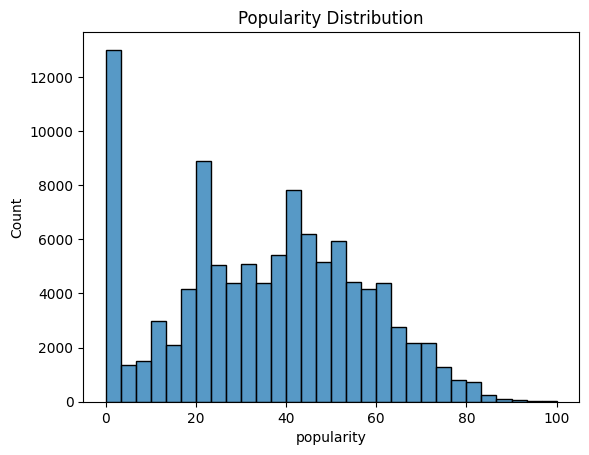

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['popularity'], bins=30)
plt.title("Popularity Distribution")
plt.show()

# Model training

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Encode the categorical 'track_genre' column
df['track_genre'] = df['track_genre'].astype('category').cat.codes

X = df.drop(['popularity'], axis=1)
y = df['popularity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (85524, 15)
Test size : (21382, 15)


# Model - XGBOOST

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("XGBoost Results:")
print("  RMSE :", round(np.sqrt(mean_squared_error(y_test, xgb_preds)), 3))
print("  R²   :", round(r2_score(y_test, xgb_preds), 3))

XGBoost Results:
  RMSE : 17.313
  R²   : 0.348


# LightGBM

In [ ]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_test)

print("LightGBM Results:")
print("  RMSE :", round(np.sqrt(mean_squared_error(y_test, lgb_preds)), 3))
print("  R²   :", round(r2_score(y_test, lgb_preds), 3))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012414 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2685
[LightGBM] [Info] Number of data points in the train set: 85524, number of used features: 15
[LightGBM] [Info] Start training from score 35.306031
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Results:
  RMSE : 17.604
  R²   : 0.325


In [ ]:
print(f"{'Model':<15} {'RMSE':>8} {'R²':>8}")
# XGBoost Row
xgb_rmse = round(np.sqrt(mean_squared_error(y_test, xgb_preds)), 3)
xgb_r2 = round(r2_score(y_test, xgb_preds), 3)
print(f"{'XGBoost':<15} {xgb_rmse:>8} {xgb_r2:>8}")

# LightGBM Row
lgb_rmse = round(np.sqrt(mean_squared_error(y_test, lgb_preds)), 3)
lgb_r2 = round(r2_score(y_test, lgb_preds), 3)
print(f"{'LightGBM':<15} {lgb_rmse:>8} {lgb_r2:>8}")


Model               RMSE       R²
XGBoost           17.313    0.348
LightGBM          17.604    0.325


# Model Decision tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Initialize models
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)

# Fit models
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

# Make predictions
dt_preds = dt_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

In [ ]:
# Helper to calculate metrics
def get_metrics(y_true, y_pred):
    rmse = round(np.sqrt(mean_squared_error(y_true, y_pred)), 3)
    r2 = round(r2_score(y_true, y_pred), 3)
    return rmse, r2

# Gather all results
results = {
    "Decision Tree": get_metrics(y_test, dt_preds),
    "Random Forest": get_metrics(y_test, rf_preds),
    "XGBoost": get_metrics(y_test, xgb_preds),
    "LightGBM": get_metrics(y_test, lgb_preds)
}

print("="*35)
print(f"{'Model':<15} {'RMSE':>8} {'R²':>8}")
print("="*35)
for model, metrics in results.items():
    print(f"{model:<15} {metrics[0]:>8} {metrics[1]:>8}")
print("="*35)

Model               RMSE       R²
Decision Tree     19.708    0.155
Random Forest     18.911    0.222
XGBoost           17.313    0.348
LightGBM          17.604    0.325


Best performance given by XGboosts

# Deployment

In [ ]:
import joblib

# Save the model
joblib.dump(xgb_model, 'xgb_model.pkl')
print("Model saved!")

Model saved!


In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 76.2 MB/s eta 0:00:00


In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("3BaWcNc5EcXrsECl0J8uNaOJDcJ_6ivUWazeogBTyRBWEob3H")


In [ ]:
%%writefile app.py

import streamlit as st
import joblib
import numpy as np

# Load model
model = joblib.load('xgb_model.pkl')

st.title("🎵 Spotify Song Popularity Predictor")
st.write("Adjust the audio features below to predict a song's popularity score!")

st.sidebar.header("🎛️ Audio Features")

# Input sliders
danceability     = st.sidebar.slider("Danceability",     0.0, 1.0, 0.5)
energy           = st.sidebar.slider("Energy",           0.0, 1.0, 0.5)
loudness         = st.sidebar.slider("Loudness (dB)",   -60.0, 0.0, -10.0)
speechiness      = st.sidebar.slider("Speechiness",      0.0, 1.0, 0.05)
acousticness     = st.sidebar.slider("Acousticness",     0.0, 1.0, 0.5)
instrumentalness = st.sidebar.slider("Instrumentalness", 0.0, 1.0, 0.0)
liveness         = st.sidebar.slider("Liveness",         0.0, 1.0, 0.1)
valence          = st.sidebar.slider("Valence",          0.0, 1.0, 0.5)
tempo            = st.sidebar.slider("Tempo (BPM)",      50.0, 220.0, 120.0)
duration_ms      = st.sidebar.slider("Duration (ms)",    60000, 600000, 210000)
explicit         = st.sidebar.selectbox("Explicit?",     [0, 1])
key              = st.sidebar.slider("Key",              0, 11, 5)
mode             = st.sidebar.selectbox("Mode",          [0, 1])
time_signature   = st.sidebar.slider("Time Signature",   1, 5, 4)

# Predict button
if st.button("🎯 Predict Popularity"):
    features = np.array([[danceability, energy, key, loudness, mode,
                          speechiness, acousticness, instrumentalness,
                          liveness, valence, tempo, time_signature,
                          duration_ms, explicit]])

    prediction = model.predict(features)[0]
    score = round(float(prediction), 1)

    st.subheader(f"Predicted Popularity Score: {score} / 100")

    # Visual feedback
    if score >= 70:
        st.success("🔥 This could be a HIT!")
    elif score >= 45:
        st.info("🎵 Decent popularity expected")
    else:
        st.warning("📉 Might not chart well")

    st.progress(int(score))

Writing app.py


In [ ]:
import subprocess
import threading
import time

# Start streamlit in background
def run():
    subprocess.run(['streamlit', 'run', 'app.py',
                    '--server.port', '8501',
                    '--server.headless', 'true'])

thread = threading.Thread(target=run)
thread.start()
time.sleep(3)

# Create public URL
public_url = ngrok.connect(8501)
print("🌐 Your app is live at:", public_url)

🌐 Your app is live at: NgrokTunnel: "https://idiomatic-patti-laudatorily.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
print(X_train.columns.tolist())

['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']
